# Welcome to Pipelines!

The HuggingFace transformers library provides APIs at two different levels.

The High Level API for using open-source models for typical inference tasks is called "pipelines". It's incredibly easy to use.

You create a pipeline using something like:

`my_pipeline = pipeline("the_task_I_want_to_do")`

Followed by

`result = my_pipeline(my_input)`

And that's it!

See end of this colab for a list of all pipelines.

## Before we start: 2 important pro-tips for using Colab:

**Pro-tip 1:**

Data Science code often gives warnings and messages. They can mostly be safely ignored! Glance over them, and if something goes wrong later, perhaps they can give you a clue.

**Pro-tip 2:**

In the middle of running a Colab, you might get an error like this:

> Runtime error: CUDA is required but not available for bitsandbytes. Please consider installing [...]

This is a super-misleading error message! Please don't try changing versions of packages...

This actually happens because Google has switched out your Colab runtime, perhaps because Google Colab was too busy. The solution is:

1. Kernel menu >> Disconnect and delete runtime
2. Reload the colab from fresh and Edit menu >> Clear All Outputs
3. Connect to a new T4 using the button at the top right
4. Select "View resources" from the menu on the top right to confirm you have a GPU
5. Rerun the cells in the colab, from the top down, starting with the pip installs

And all should work great - otherwise, ask me!


## A sidenote:

You may already know this, but just in case you're not familiar with the word "inference" that I use here:

When working with Data Science models, you could be carrying out 2 very different activities: **training** and **inference**.

### 1. Training  

**Training** is when you provide a model with data for it to adapt to get better at a task in the future. It does this by updating its internal settings - the parameters or weights of the model. If you're Training a model that's already had some training, the activity is called "fine-tuning".

### 2. Inference

**Inference** is when you are working with a model that has _already been trained_. You are using that model to produce new outputs on new inputs, taking advantage of everything it learned while it was being trained. Inference is also sometimes referred to as "Execution" or "Running a model".

All of our use of APIs for GPT, Claude and Gemini in the last weeks are examples of **inference**. The "P" in GPT stands for "Pre-trained", meaning that it has already been trained with data (lots of it!) In week 6 we will try fine-tuning GPT ourselves.
  
The pipelines API in HuggingFace is only for use for **inference** - running a model that has already been trained. In week 7 we will be training our own model, and we will need to use the more advanced HuggingFace APIs that we look at in the up-coming lecture.

I recorded this playlist on YouTube with more on parameters, training and inference:  
https://www.youtube.com/playlist?list=PLWHe-9GP9SMMdl6SLaovUQF2abiLGbMjs


In [1]:
# Pip installs should come at the top line.
# If your Kernel ever resets, you need to run this again.

!pip install -q --upgrade datasets==3.6.0
!sudo apt install tesseract-ocr
!pip install pytesseract


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [ ]:
# Let's check the GPU - it should be a Tesla T4

gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)
  if gpu_info.find('Tesla T4') >= 0:
    print("Success - Connected to a T4")
  else:
    print("NOT CONNECTED TO A T4")

In [ ]:
# Imports

import torch
from google.colab import userdata
from huggingface_hub import login
from transformers import pipeline
from diffusers import DiffusionPipeline
from datasets import load_dataset
import soundfile as sf
from IPython.display import Audio
import os

from dotenv import load_dotenv
load_dotenv()

# Important Note - Hugging Face account

In Day 1, we set up a FREE account on https://huggingface.co

### If you skipped this:

Please go back and do it! Then go to the Avatar menu, Tokens, and create an API token.. And make sure it has WRITE permissions! And then add it to the secrets on the left by pressing the key button.

### If you did this (thank you!)

Click on the Key button and turn on the switch so that this notebook gets access to your Hugging Face key.

In [ ]:
# Colab GUI
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')

In [2]:
# local VS_Code
import getpass
hf_token = getpass.getpass("Enter HF Token: ")

In [3]:
from huggingface_hub import login

if hf_token and hf_token.startswith("hf_"):
  print("HF key looks good so far")
else:
  print("HF key is not set - please click the key in the left sidebar")
login(hf_token, add_to_git_credential=True)

HF key looks good so far


## Using Pipelines from Hugging Face

A simple way to run inference for common tasks, without worrying about all the plumbing, picking reasonable defaults.


### How it works:

STEP 1: Create a pipeline - a function you can then call

```python
my_pipeline = pipeline(task, model=xx, device=xx)
```

If you don't specify a model, then Hugging Face picks one for you that's the default for the task. Specify "cuda" for the device to use an NVIDIA GPU like the one on the T4. Specify "mps" on a Mac.


STEP 2: Then call it as many times as you want:

```python
my_pipeline(input1)
my_pipeline(input2)
```

In [ ]:
# Sentiment Analysis

my_simple_sentiment_analyzer = pipeline("sentiment-analysis", device="cuda")
result = my_simple_sentiment_analyzer("I'm super excited to be on the way to LLM mastery!")
print(result)

In [ ]:
result = my_simple_sentiment_analyzer("I am not really excited on the way to LLM mastery!")
print(result)

In [ ]:

better_sentiment = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment", device="cuda")
result = better_sentiment("I should be more excited to be on the way to LLM mastery!!")
print(result)

In [ ]:
ms_sentiment = pipeline("sentiment-analysis", model="microsoft/deberta-xlarge-mnli", device="cuda")
result = ms_sentiment("I should be more excited to be on the way to LLM mastery!!")
print(result)



In [ ]:
# with dataset
import datasets
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
from tqdm.auto import tqdm

ds = load_dataset("mteb/tweet_sentiment_extraction")

for i in tqdm(range(10)):
    print(ds['train'][i])
    print(str(better_sentiment(ds["train"][i]["text"]))+ ' ' + str(ds["train"][i]["label"]))

In [ ]:
# Named Entity Recognition

ner = pipeline("ner", device="cuda", model="Babelscape/wikineural-multilingual-ner")
result = ner("AI Engineers are learning about the amazing pipelines from HuggingFace in Google Colab from Ed Donner")
for entity in result:
  print(entity)

In [ ]:
# Question Answering with Context

question="What is the capital of Germany?"
context="The capital of France is Paris."

question_answerer = pipeline("question-answering", device="cuda")
result = question_answerer(question=question, context=context)
print(result)

In [ ]:
# Text Summarization

summarizer = pipeline("summarization", device="cuda")
text = """
The Hugging Face transformers library is an incredibly versatile and powerful tool for natural language processing (NLP).
It allows users to perform a wide range of tasks such as text classification, named entity recognition, and question answering, among others.
It's an extremely popular library that's widely used by the open-source data science community.
It lowers the barrier to entry into the field by providing Data Scientists with a productive, convenient way to work with transformer models.
"""
summary = summarizer(text, max_length=50, min_length=25, do_sample=False)
print(summary[0]['summary_text'])

In [ ]:
# Translation

translator = pipeline("translation_en_to_de", device="cuda")
result = translator("The Data Scientists were truly amazed by the power and simplicity of the HuggingFace pipeline API.")
print(result[0]['translation_text'])

In [ ]:
# Another translation, showing a model being specified
# All translation models are here: https://huggingface.co/models?pipeline_tag=translation&sort=trending

translator = pipeline("translation_en_to_es", model="Helsinki-NLP/opus-mt-en-es", device="cuda")
result = translator("The Data Scientists were truly amazed by the power and simplicity of the HuggingFace pipeline API.")
print(result[0]['translation_text'])

In [ ]:
# Classification

classifier = pipeline("zero-shot-classification", device="cuda")
result = classifier("Donal Trump plays BasketBall with OpenAI CEO Sam Altman.", candidate_labels=["technology", "sports", "politics"])
print(result)

In [ ]:
# Text Generation

generator = pipeline("text-generation", device="cuda")
result = generator("The most important thing in life is")
print(result[0]['generated_text'])

In [ ]:
# Image Generation - remember this?! Now you know what's going on
# Pipelines can be used for diffusion models as well as transformers

from IPython.display import display
from diffusers import AutoPipelineForText2Image
import torch

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
pipe.to("cuda")
prompt = "A class of students learning AI engineering in an absolute fotorealistic style"
image = pipe(prompt=prompt, num_inference_steps=4, guidance_scale=0.0).images[0]
display(image)

In [ ]:
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

In [ ]:
from transformers import pipeline

# "openai/whisper-tiny" is a small, fast model for ASR
transcriber = pipeline("automatic-speech-recognition", model="openai/whisper-tiny", device="cuda")

# You can pass a local file path or a URL
result = transcriber("https://huggingface.co/datasets/Narsil/asr_dummy/resolve/main/mlk.flac")

print(result)
# Output: {'text': ' I HAVE A DREAM THAT ONE DAY THIS NATION WILL RISE UP...'}

In [12]:
# Audio Generation

from transformers import pipeline
from datasets import load_dataset
import soundfile as sf
import torch
from IPython.display import Audio

synthesiser = pipeline("text-to-speech", "microsoft/speecht5_tts", device='cuda')
embeddings_dataset = load_dataset("matthijs/cmu-arctic-xvectors", split="validation", trust_remote_code=True)
speaker_embedding = torch.tensor(embeddings_dataset[7306]["xvector"]).unsqueeze(0)
speech = synthesiser("Hi to an artificial intelligence engineer, on the way to mastery!", forward_params={"speaker_embeddings": speaker_embedding})

Audio(speech["audio"], rate=speech["sampling_rate"])

Device set to use cuda


In [ ]:
!sudo apt install tesseract-ocr
!pip install pytesseract

In [6]:
import torch
from transformers import pipeline
from PIL import Image
import requests
import pytesseract


# Initialize the pipeline for visual documents (invoices, PDFs)
doc_qa = pipeline(
    "document-question-answering", 
    model="impira/layoutlm-document-qa", 
    device="cuda"
)

# Load a sample invoice image
url = "https://templates.invoicehome.com/invoice-template-us-neat-750px.png"
image = Image.open(requests.get(url, stream=True).raw)

# Ask questions about the visual layout
result = doc_qa(
    image=image, 
    question="What is the total amount due?"
)

print(result)
# Output: [{'score': 0.99..., 'answer': '$1,234.56', 'start': ...}]

Device set to use cuda


[{'score': 0.9281503558158875, 'answer': '$154.06', 'start': 75, 'end': 75}]


In [ ]:
import requests
from PIL import Image, ImageDraw, ImageFont
from transformers import pipeline

# 1. Load an image
# We'll use a URL for a similar busy market scene to make the code reproducible.
image_url = "https://c8.alamy.com/comp/B0CHHG/borough-market-southwark-london-england-uk-B0CHHG.jpg"
try:
    image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")
except Exception as e:
    print(f"Error loading image: {e}")
    exit()

# 2. Initialize the object detection pipeline
# We use the standard 'facebook/detr-resnet-50' model.
# You can specify device=0 to use a GPU if available.
model_name = "facebook/detr-resnet-50"
object_detector = pipeline("object-detection", model=model_name, device="cuda")

# 3. Run inference on the image
print("Running object detection. This may take a moment...")
results = object_detector(image)

# 4. Function to draw bounding boxes and labels on the image
def draw_boxes(image, results, threshold=0.85):
    """
    Draws bounding boxes and labels on an image based on detection results.
    A threshold is used to filter out low-confidence detections.
    """
    draw = ImageDraw.Draw(image)
    # Try to load a font, fall back to default if not found
    try:
        # For standard Linux systems
        font = ImageFont.truetype("DejaVuSans-Bold.ttf", 20)
    except IOError:
        # Fallback for other systems or if font is missing
        font = ImageFont.load_default()
        print("Using default font.")

    for result in results:
        score = result['score']
        label = result['label']
        box = result['box']

        # Filter detected objects by a confidence threshold
        if score < threshold:
            continue

        # Unpack box coordinates
        xmin, ymin, xmax, ymax = box['xmin'], box['ymin'], box['xmax'], box['ymax']

        # Generate a unique color based on the label for distinction
        label_color = (
            hash(label) % 256,
            hash(label + "g") % 256,
            hash(label + "b") % 256
        )

        # Draw the bounding box
        # width controls the thickness of the outline
        draw.rectangle(((xmin, ymin), (xmax, ymax)), outline=label_color, width=4)

        # Create the label text with score
        label_text = f"{label} {score:.2f}"

        # Calculate text size to create a background box for readability
        # Use getbbox if available (newer Pillow versions), else fallback
        if hasattr(font, 'getbbox'):
             text_bbox = font.getbbox(label_text)
             text_width = text_bbox[2] - text_bbox[0]
             text_height = text_bbox[3] - text_bbox[1]
        else:
             text_width, text_height = font.getsize(label_text)

        # Draw a filled rectangle behind the text for better contrast
        draw.rectangle(
            ((xmin, ymin - text_height - 4), (xmin + text_width + 8, ymin)),
            fill=label_color
        )
        # Draw the text label
        draw.text((xmin + 4, ymin - text_height - 2), label_text, fill="white", font=font)

    return image

# 5. Visualize and display the results
# Set a threshold to only show high-confidence detections
annotated_image = draw_boxes(image.copy(), results, threshold=0.85)

# Display the final image with bounding boxes


# Optionally save the image
# annotated_image.save("detected_objects.jpg")
print("Object detection complete. Displaying resulting image.")
annotated_image

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pas

Running object detection. This may take a moment...
Using default font.
Object detection complete. Displaying resulting image.


# All the available pipelines

Here are all the pipelines available from Transformers and Diffusers.

With thanks to student Lucky P for suggesting I include this!

There's a list pipelines under the Tasks on this page (you have to scroll down a bit, then expand the parameters to see the Tasks):

https://huggingface.co/docs/transformers/main_classes/pipelines

There's also this list of Tasks for Diffusion models instead of Transformers, following the image generation example where I use DiffusionPipeline above.

https://huggingface.co/docs/diffusers/en/api/pipelines/overview

If you come up with some cool examples of other pipelines, please share them with me! It's wonderful how HuggingFace makes this advanced AI functionality available for inference with such a simple API.

In [ ]:
# Layered Example for Audio Processing

import torch
from transformers import pipeline
from datasets import load_dataset
import soundfile as sf

# Check for GPU
device = 0 if torch.cuda.is_available() else -1

print("Initializing pipelines... (this may take a minute)")

# 1. AUDIO TRANSCRIPTION (ASR)
# We use OpenAI's Whisper (tiny version) for fast, accurate transcription
transcriber = pipeline(
    "automatic-speech-recognition", 
    model="openai/whisper-tiny",
    device=device
)

# 2. SENTIMENT ANALYSIS
# Determines if the feedback is Positive or Negative
sentiment_analyzer = pipeline(
    "text-classification", 
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device
)

# 3. NAMED ENTITY RECOGNITION (NER)
# Extracts specific names, locations, and organizations
ner_tagger = pipeline(
    "token-classification", 
    model="dslim/bert-base-NER", 
    aggregation_strategy="simple",
    device=device
)

# --- SIMULATE INPUT DATA ---
# We will download a sample audio file from a Hugging Face dataset.
# In a real app, this would be your "voicemail.mp3"
dataset = load_dataset("hf-internal-testing/librispeech_asr_dummy", "clean", split="validation")
sample_audio = dataset[72]["audio"]["array"]
sample_rate = dataset[72]["audio"]["sampling_rate"]


print("\n--- PROCESSING CUSTOMER AUDIO ---")

# STEP 1: Transcribe
# We pass the raw audio data and sampling rate to the pipeline
transcription_result = transcriber({"raw": sample_audio, "sampling_rate": sample_rate})
transcript = transcription_result["text"]

print(f"📝 Transcript: \"{transcript}\"")

# STEP 2: Analyze Sentiment
sentiment_result = sentiment_analyzer(transcript)
label = sentiment_result[0]['label']
score = sentiment_result[0]['score']

# Logic: If negative and high confidence, flag as URGENT
priority = "URGENT" if label == "NEGATIVE" and score > 0.8 else "NORMAL"

print(f"heart_decoration Sentiment: {label} (Confidence: {score:.2f})")
print(f"rotating_light Priority Level: {priority}")

# STEP 3: Extract Key Entities (Products/Locations/Names)
entities = ner_tagger(transcript)

print("mag_right Detected Entities:")
if entities:
    for entity in entities:
        print(f"   - {entity['entity_group']}: {entity['word']} (Confidence: {entity['score']:.2f})")
else:
    print("   - No specific entities detected.")

Audio(sample_audio, rate=sample_rate)

Initializing pipelines... (this may take a minute)


Device set to use cuda:0
Device set to use cuda:0
Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0



--- PROCESSING CUSTOMER AUDIO ---
📝 Transcript: " Then the powerful twist that's for us to decide in and under the guard."
heart_decoration Sentiment: POSITIVE (Confidence: 1.00)
rotating_light Priority Level: NORMAL
mag_right Detected Entities:
   - No specific entities detected.


In [27]:
!pip install transformers torch pillow scipy sentencepiece soundfile accelerate sacremoses bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 13.5 MB/s eta 0:00:00:00:0100:01


In [4]:
!pip install -U bitsandbytes

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


Lade große Modelle... (Das kann 1-2 Minuten dauern)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda:0
Device set to use cuda
Device set to use cuda



--- ANALYSE STARTET ---


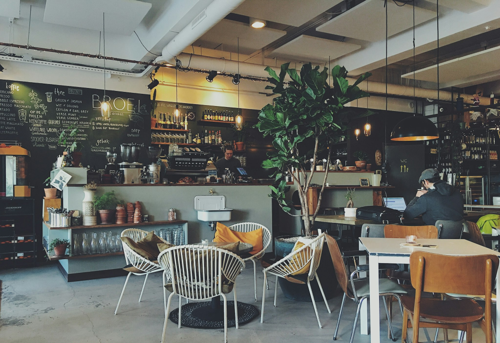

👁️ Analysiere Bilddetails...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


🇺🇸 Detaillierte Beschreibung: a restaurant with tables and chairs in front of a chalkboard wall with a large plant in the middle of the room. a man is sitting at a table in the middle of the room. a woman is sitting at a table in the back of the room

🧠 Übersetze kontextuell...
🇩🇪 Deutsche Übersetzung:    ein restaurant mit tischen und stühlen vor einer tafelwand mit einer großen pflanze in der mitte im raum. ein mann sitzt an einem tisch mitten im raum, an einem tisch in der tafel. eine frau sitzt an einem tisch in der tafel. eine frau an einem tisch in der tafel. eine frau an einem tisch in der hinteren in der tafeltafeltisch in der tafeltisch in der hinteren im raum. eine frau an der hinteren des raum. eine frau an der hinteren im raum ist eine eine eine eine eine eine eine eine frau an einem tisch, eine eine eine frau an einem tisch, eine eine eine eine eine frau, eine eine Frau an ein ein ein ein ein ein ein ein ein ein ein ein ein. ein ein. ein der tisch, ein ein ein der tisch, e

In [7]:
# --- SCHRITT 0: INSTALLATION FÜR GROSSE MODELLE ---
# Wir benötigen 'sacremoses' für das hochwertige Übersetzungsmodell
# !pip install transformers torch pillow scipy sentencepiece soundfile accelerate sacremoses

import torch
import numpy as np
import requests
from PIL import Image
from transformers import pipeline
from IPython.display import Audio, display

# 1. GPU PRÜFUNG & KONFIGURATION
# Wir erzwingen die Nutzung der GPU, da diese Modelle für die CPU zu schwer sind.
device = "cuda"

# 2. PRO-MODELLE LADEN
print("Lade große Modelle... (Das kann 1-2 Minuten dauern)")

# A. VISION: BLIP Large (Genauer & detaillierter)
# ~1.8 GB VRAM
captioner = pipeline(
    "image-to-text", 
    model="Salesforce/blip2-opt-2.7b", 
    model_kwargs={"load_in_8bit": True} # Optional: saves memory
)

# B. ÜBERSETZUNG: WMT19 Winner (Facebook)
# Viel besseres Verständnis von Kontext und Grammatik als Opus
# ~1.2 GB VRAM
translator = pipeline(
    "translation_en_to_de",
    model="facebook/wmt19-en-de",
    device=device
)

# C. AUDIO: MMS Deutsch
tts = pipeline(
    "text-to-speech",
    model="facebook/mms-tts-deu",
    device=device
)

# 3. VERARBEITUNGSLOGIK
def pro_analyse(bild_url):
    print("\n--- ANALYSE STARTET ---")

    # Bild laden
    try:
        raw_image = Image.open(requests.get(bild_url, stream=True).raw).convert('RGB')
        display_image = raw_image.copy()
        display_image.thumbnail((500, 500)) # Etwas größer anzeigen
        display(display_image)
    except Exception as e:
        print(f"Fehler: {e}")
        return

    # A. Detaillierte Beschreibung generieren
    # Wir erlauben mehr Tokens (Wörter), da das Large-Modell gesprächiger ist
    print("👁️ Analysiere Bilddetails...")
    captions = captioner(raw_image, generate_kwargs={"max_new_tokens": 500, "min_new_tokens": 40})
    english_text = captions[0]['generated_text']
    print(f"🇺🇸 Detaillierte Beschreibung: {english_text}")

    # B. Hochwertige Übersetzung
    print("🧠 Übersetze kontextuell...")
    trans_output = translator(english_text)
    german_text = trans_output[0]['translation_text']
    print(f"🇩🇪 Deutsche Übersetzung:    {german_text}")

    # C. Audio
    print("🔊 Generiere HD Audio...")
    tts_output = tts(german_text)
    audio_data = tts_output['audio']
    sampling_rate = tts_output['sampling_rate']

    if isinstance(audio_data, np.ndarray) and audio_data.ndim > 1:
        audio_data = audio_data.squeeze()

    return Audio(data=audio_data, rate=sampling_rate)

# 4. TESTLAUF
# Ein komplexeres Bild, um die Stärke der Modelle zu testen (Café-Szene)
url = "https://images.unsplash.com/photo-1554118811-1e0d58224f24?q=80&w=2047&auto=format&fit=crop"

pro_analyse(url)